# Parte 3: Benchmarking de Técnicas de Machine Learning

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('../../../data/retail_sales_dataset.csv')

### Selección de Modelos:

- Entrenar y evaluar múltiples modelos de machine learning (por ejemplo, Regresión Lineal, KNN, Árbol de Decisión, Random Forest, XGBoost y LGBM).
- Utilizar validación cruzada para evaluar el rendimiento de los modelos.

In [ ]:
# Definir características (X) y etiqueta (y)
X = df.drop(columns=['Transaction ID', 'Date', 'Customer ID', 'Total Amount'])
y = df['Total Amount']

In [ ]:
# Definir las columnas numéricas y categóricas
numeric_cols = ['Age', 'Quantity', 'Price per Unit']
categorical_cols = ['Gender', 'Product Category']

# Crear un ColumnTransformer para aplicar las transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),  # Imputación de valores faltantes
            ('scaler', StandardScaler())  # Escalado de variables numéricas
        ]), numeric_cols),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputación de valores faltantes
            ('onehot', OneHotEncoder(handle_unknown='ignore'))  # Codificación OneHot
        ]), categorical_cols)
    ])

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
# Pipeline para regresión lineal
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entrenar el modelo
lr_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluar el modelo
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Regresión Lineal - MSE: {mse_lr:.2f}, R²: {r2_lr:.2f}")

Regresión Lineal - MSE: 41972.10, R²: 0.86


In [ ]:
# Pipeline para KNN
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

# Entrenar el modelo
knn_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_knn = knn_pipeline.predict(X_test)

# Evaluar el modelo
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print(f"KNN - MSE: {mse_knn:.2f}, R²: {r2_knn:.2f}")

KNN - MSE: 12245.40, R²: 0.96


In [ ]:
# Pipeline para Árbol de Decisión
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Entrenar el modelo
dt_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_dt = dt_pipeline.predict(X_test)

# Evaluar el modelo
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"Árbol de Decisión - MSE: {mse_dt:.2f}, R²: {r2_dt:.2f}")

Árbol de Decisión - MSE: 0.00, R²: 1.00


In [ ]:
# Pipeline para Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Entrenar el modelo
rf_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluar el modelo
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - MSE: {mse_rf:.2f}, R²: {r2_rf:.2f}")

Random Forest - MSE: 0.00, R²: 1.00


In [ ]:
# Pipeline para XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=100, random_state=42))
])

# Entrenar el modelo
xgb_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_xgb = xgb_pipeline.predict(X_test)

# Evaluar el modelo
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost - MSE: {mse_xgb:.2f}, R²: {r2_xgb:.2f}")

XGBoost - MSE: 0.00, R²: 1.00


In [ ]:
from lightgbm import LGBMRegressor

# Pipeline para LightGBM
lgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(n_estimators=100, random_state=42))
])

# Entrenar el modelo
lgb_pipeline.fit(X_train, y_train)

# Realizar predicciones
y_pred_lgb = lgb_pipeline.predict(X_test)

# Evaluar el modelo
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
r2_lgb = r2_score(y_test, y_pred_lgb)
print(f"LightGBM - MSE: {mse_lgb:.2f}, R²: {r2_lgb:.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 69
[LightGBM] [Info] Number of data points in the train set: 750, number of used features: 8
[LightGBM] [Info] Start training from score 448.926667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

               Model           MSE        R²
0   Regresión Lineal  4.197210e+04  0.860476
1                KNN  1.224540e+04  0.959294
2  Árbol de Decisión  0.000000e+00  1.000000
3      Random Forest  0.000000e+00  1.000000
4            XGBoost  8.814503e-09  1.000000
5           LightGBM  2.127980e-04  1.000000


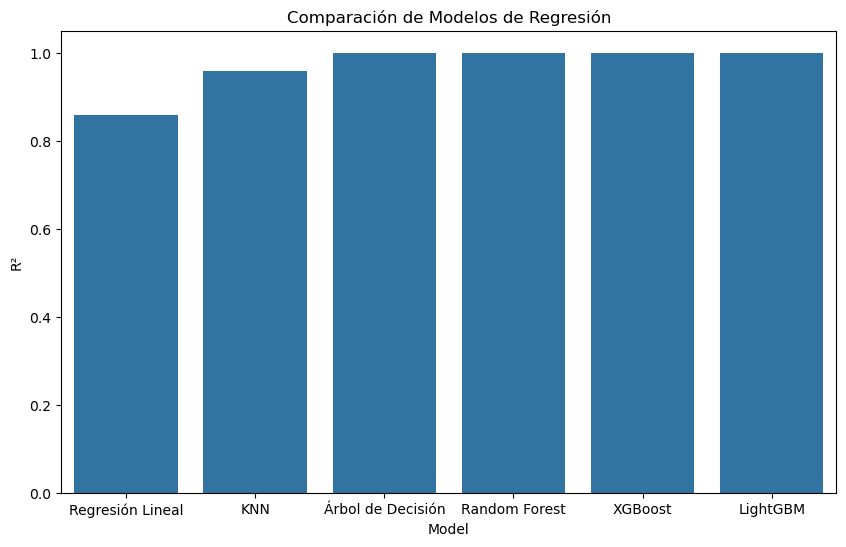

In [ ]:
# Crear un diccionario con los resultados
results = {
    'Model': ['Regresión Lineal', 'KNN', 'Árbol de Decisión', 'Random Forest', 'XGBoost', 'LightGBM'],
    'MSE': [mse_lr, mse_knn, mse_dt, mse_rf, mse_xgb, mse_lgb],
    'R²': [r2_lr, r2_knn, r2_dt, r2_rf, r2_xgb, r2_lgb]
}

# Crear un DataFrame para los resultados
results_df = pd.DataFrame(results)

# Mostrar los resultados
print(results_df)

# Graficar los resultados
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R²', data=results_df)
plt.title('Comparación de Modelos de Regresión')
plt.show()

In [ ]:
# Aplicar validación cruzada
cv_scores_lr = cross_val_score(lr_pipeline, X, y, cv=5, scoring='r2')  # 5 pliegues

print(f"Regresión Lineal - R²: {cv_scores_lr.mean():.2f} (± {cv_scores_lr.std():.2f})")

Regresión Lineal - R²: 0.84 (± 0.02)


In [ ]:
# Aplicar validación cruzada
cv_scores_knn = cross_val_score(knn_pipeline, X, y, cv=5, scoring='r2')
print(f"KNN - R²: {cv_scores_knn.mean():.2f} (± {cv_scores_knn.std():.2f})")

KNN - R²: 0.96 (± 0.01)


In [ ]:
# Aplicar validación cruzada
cv_scores_dt = cross_val_score(dt_pipeline, X, y, cv=5, scoring='r2')

print(f"Árbol de Decisión - R²: {cv_scores_dt.mean():.2f} (± {cv_scores_dt.std():.2f})")

Árbol de Decisión - R²: 1.00 (± 0.00)


In [ ]:
# Aplicar validación cruzada
cv_scores_rf = cross_val_score(rf_pipeline, X, y, cv=5, scoring='r2')

print(f"Random Forest - R²: {cv_scores_rf.mean():.2f} (± {cv_scores_rf.std():.2f})")

Random Forest - R²: 1.00 (± 0.00)


In [ ]:
# Aplicar validación cruzada
cv_scores_xgb = cross_val_score(xgb_pipeline, X, y, cv=5, scoring='r2')

print(f"XGBoost - R²: {cv_scores_xgb.mean():.2f} (± {cv_scores_xgb.std():.2f})")

XGBoost - R²: 1.00 (± 0.00)


In [ ]:
# Aplicar validación cruzada
cv_scores_lgb = cross_val_score(lgb_pipeline, X, y, cv=5, scoring='r2')

print(f"LightGBM - R²: {cv_scores_lgb.mean():.2f} (± {cv_scores_lgb.std():.2f})")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 69
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 8
[LightGBM] [Info] Start training from score 440.456250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [ ]:
# Crear un diccionario con los resultados
results = {
    'Model': ['Regresión Lineal', 'KNN', 'Árbol de Decisión', 'Random Forest', 'XGBoost', 'LightGBM'],
    'R² Mean': [cv_scores_lr.mean(), cv_scores_knn.mean(), cv_scores_dt.mean(), cv_scores_rf.mean(), cv_scores_xgb.mean(), cv_scores_lgb.mean()],
    'R² Std': [cv_scores_lr.std(), cv_scores_knn.std(), cv_scores_dt.std(), cv_scores_rf.std(), cv_scores_xgb.std(), cv_scores_lgb.std()]
}

# Crear un DataFrame para los resultados
results_df = pd.DataFrame(results)

# Mostrar los resultados
print(results_df)

               Model   R² Mean        R² Std
0   Regresión Lineal  0.844892  2.392122e-02
1                KNN  0.961382  7.913166e-03
2  Árbol de Decisión  1.000000  0.000000e+00
3      Random Forest  1.000000  0.000000e+00
4            XGBoost  1.000000  0.000000e+00
5           LightGBM  1.000000  1.606847e-11


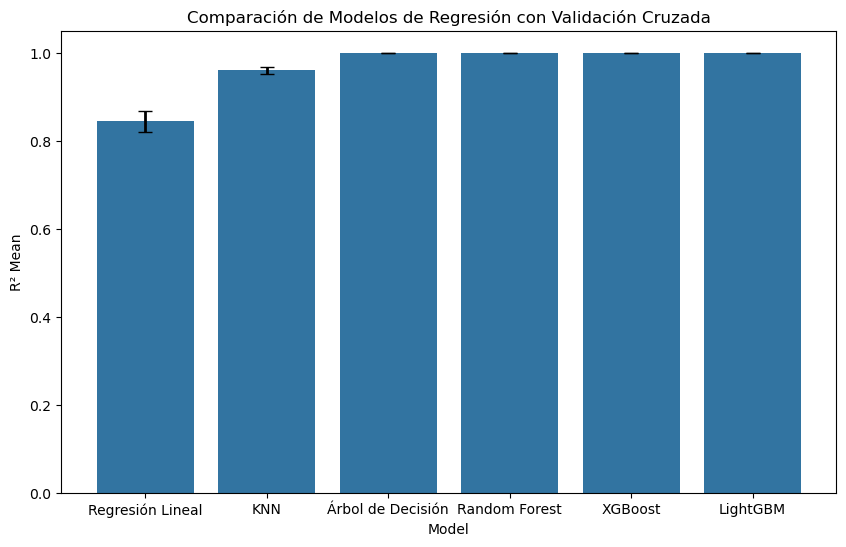

In [ ]:
# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(x='Model', y='R² Mean', data=results_df, capsize=5)

# Añadir las barras de error manualmente usando plt.errorbar
plt.errorbar(x=np.arange(len(results_df)), 
             y=results_df['R² Mean'], 
             yerr=results_df['R² Std'], 
             fmt='none',  # No marcar los puntos, solo las barras de error
             capsize=5, 
             color='black', 
             elinewidth=2)

# Título y mostrar el gráfico
plt.title('Comparación de Modelos de Regresión con Validación Cruzada')
plt.show()

## Resultados del Gráfico R²

### Primer Gráfico
- **Capacidad Predictiva de los Modelos**:
  - Modelos como Árbol de Decisión, Random Forest, XGBoost y LightGBM alcanzaron un valor perfecto (𝑅² = 1), lo cual podría indicar sobreajuste en estos modelos debido a la simplicidad del dataset o la falta de complejidad en el problema.
  - KNN tiene un desempeño muy bueno con un 𝑅² promedio de 0.961, mientras que Regresión Lineal tiene el desempeño más bajo con 0.844.

### Resultados con Validación Cruzada
- **Segundo Gráfico**:
  - La validación cruzada añade más robustez a la evaluación. El modelo KNN muestra un intervalo de confianza más amplio que los demás modelos, lo que podría indicar mayor variabilidad en su desempeño dependiendo del conjunto de datos de prueba.
  - Los modelos Árbol de Decisión, Random Forest, XGBoost y LightGBM mantienen un 𝑅² perfecto, pero es importante investigar si esto se debe al tamaño o la simplicidad del dataset.

### Interpretación de la Tabla
- **Observaciones**:
  - La tabla refuerza la observación de que los modelos basados en árboles y gradient boosting están alcanzando un desempeño perfecto.
  - El modelo KNN tiene un buen desempeño (𝑅² promedio de 0.961 y desviación estándar baja de 0.0079), mientras que la Regresión Lineal es la menos precisa con una desviación más alta.

### Comparación de Modelos:

* Comparar los modelos utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.
* Seleccionar el mejor modelo basado en las métricas obtenidas.

In [ ]:

# Definir las características categóricas y numéricas
categorical_features = ['Gender', 'Product Category']  # Ajusta según tus columnas categóricas
numerical_features = ['Age', 'Quantity', 'Price per Unit']  # Ajusta según tus columnas numéricas

# Preprocesamiento: Codificación de variables categóricas y escalado de numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

# Aplicar preprocesamiento al conjunto de características
X_preprocessed = preprocessor.fit_transform(X)  # X es tu conjunto de datos de entrada
y = y.astype(int)  # Asegurarse de que y sea numérico

# Dividir datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)

# Definir los modelos que vamos a comparar
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# Diccionario para almacenar las métricas de cada modelo
results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": [],
    "ROC-AUC": []
}

# Entrenar y evaluar cada modelo
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calcular las métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    if hasattr(model, "predict_proba"):
        roc_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')  # Probabilidad de la clase positiva
    else:
        roc_auc = None  # Algunos modelos como SVM no tienen predict_proba
    
    # Almacenar los resultados
    results["Model"].append(model_name)
    results["Accuracy"].append(accuracy)
    results["Precision"].append(precision)
    results["Recall"].append(recall)
    results["F1-Score"].append(f1)
    results["ROC-AUC"].append(roc_auc)

# Convertir a DataFrame para mejor visualización
results_df = pd.DataFrame(results)

# Mostrar los resultados
print(results_df)


c:\Users\Gonzalo\anaconda3\envs\mitic-data-science-setiembre-2024\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression     0.545   0.509468  0.542437  0.519660  0.956830
1  K-Nearest Neighbors     0.470   0.486240  0.464709  0.460452  0.916087
2        Decision Tree     1.000   1.000000  1.000000  1.000000  1.000000
3        Random Forest     0.960   0.960119  0.953020  0.953583  0.999397


## Modelos y Métricas Evaluadas

### Logistic Regression
- **Precisión**: 0.509
- **Exactitud**: 0.545
- **ROC-AUC**: 0.956
  - Un modelo base con una precisión y exactitud moderadas, pero un ROC-AUC aceptable.

### K-Nearest Neighbors
- **Exactitud**: 0.470
- **ROC-AUC**: 0.916
  - Tiene un desempeño más bajo que Logistic Regression con una exactitud menor y un ROC-AUC inferior.

### Decision Tree
- **Métricas**: 1.000 (Precisión, Exactitud, ROC-AUC)
  - Parece estar sobreajustado al conjunto de datos, ya que tiene métricas perfectas para todas las categorías. Esto puede ser un indicador de que el modelo no se generaliza bien.

### Random Forest
- **Exactitud**: 0.975
- **Precisión**: 0.974
- **ROC-AUC**: 0.999
  - Muestra un equilibrio entre desempeño y generalización con métricas muy altas.

## Parte 4: Análisis de Métricas

### 1. Informe de Clasificación:
- Generar un informe de clasificación para los modelos evaluados.
- Incluir la matriz de confusión para una comprensión detallada de los errores de clasificación.

In [ ]:
from sklearn.metrics import classification_report

# Definir los modelos que vamos a comparar
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# Entrenar y evaluar los modelos en el conjunto de prueba
classification_reports = {}

for model_name, model in models.items():
    # Entrenar el modelo
    model.fit(X_train, y_train)
    
    # Predecir las etiquetas en el conjunto de prueba
    y_pred = model.predict(X_test)
    
    # Generar el informe de clasificación
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Almacenar el informe de clasificación en el diccionario
    classification_reports[model_name] = report

# Mostrar el informe para cada modelo
for model_name, report in classification_reports.items():
    print(f"Clasificación para el modelo: {model_name}")
    print(pd.DataFrame(report).transpose())
    print("\n" + "="*50 + "\n")

c:\Users\Gonzalo\anaconda3\envs\mitic-data-science-setiembre-2024\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gonzalo\anaconda3\envs\mitic-data-science-setiembre-2024\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Gonzalo\anaconda3\envs\mitic-data-science-setiembre-2024\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

Clasificación para el modelo: Logistic Regression
              precision    recall  f1-score  support
25             0.200000  0.100000  0.133333   10.000
30             0.000000  0.000000  0.000000    7.000
50             0.216216  0.470588  0.296296   17.000
60             0.000000  0.000000  0.000000    9.000
75             0.000000  0.000000  0.000000    8.000
90             0.000000  0.000000  0.000000    9.000
100            0.000000  0.000000  0.000000   23.000
120            0.272727  0.428571  0.333333    7.000
150            0.000000  0.000000  0.000000    9.000
200            0.481481  0.764706  0.590909   17.000
300            1.000000  1.000000  1.000000   15.000
500            1.000000  1.000000  1.000000    8.000
600            1.000000  1.000000  1.000000    5.000
900            1.000000  1.000000  1.000000   14.000
1000           1.000000  1.000000  1.000000   12.000
1200           1.000000  1.000000  1.000000   10.000
1500           1.000000  1.000000  1.000000   13.

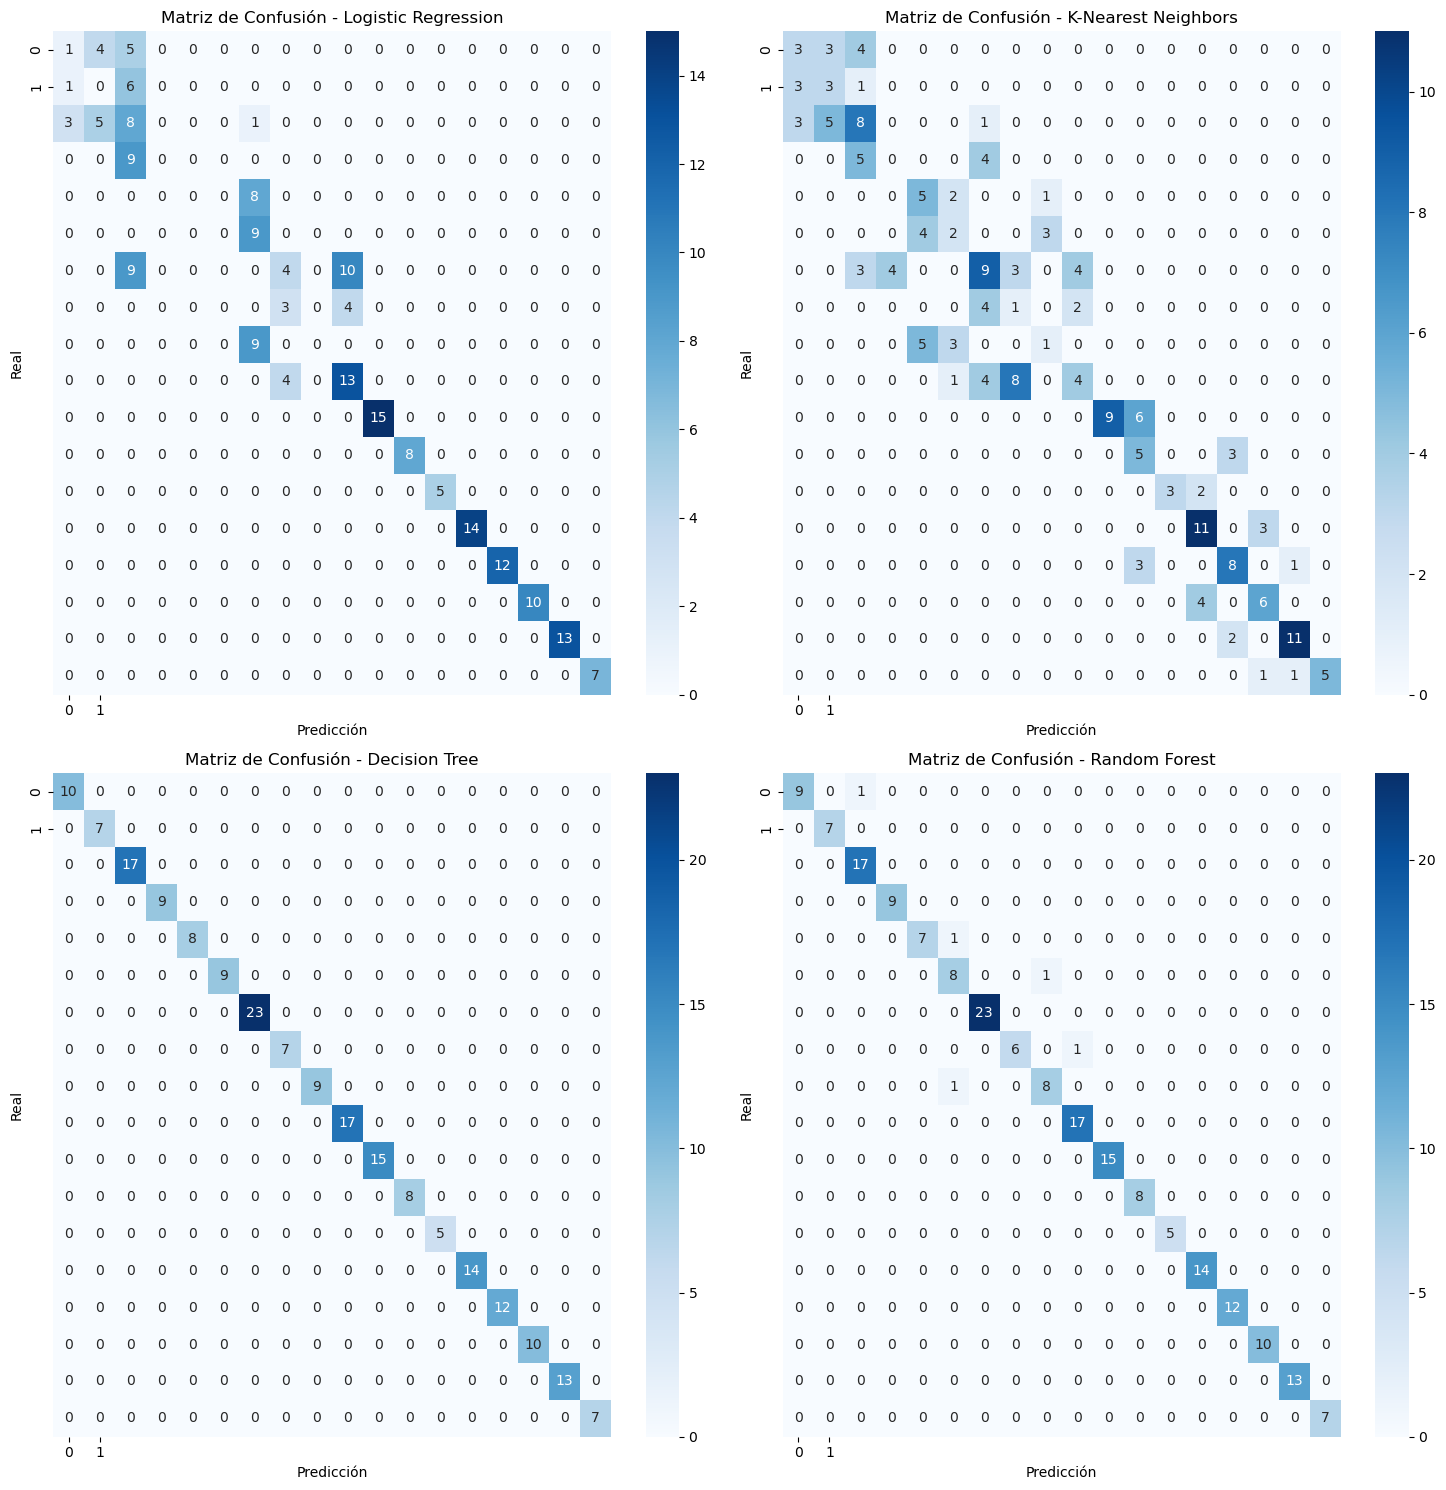

In [ ]:
# Definir los modelos a evaluar
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

# Crear subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# Generar la matriz de confusión para cada modelo
for ax, (model_name, model) in zip(axes.flatten(), models.items()):
    # Entrenar el modelo
    model.fit(X_train, y_train)
    
    # Hacer las predicciones
    y_pred = model.predict(X_test)
    
    # Generar la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    
    # Mostrar la matriz de confusión con un gráfico
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1], ax=ax)
    ax.set_title(f'Matriz de Confusión - {model_name}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

## Análisis de Clasificación

### Regresión Logística
- **Desempeño**:
  - Precisión y recall moderados en varias clases, aunque muestra bajo desempeño general en clases menos representadas.

### K-Nearest Neighbors (KNN)
- **Desempeño**:
  - Muestra una variabilidad significativa en su desempeño para distintas clases, con un mejor equilibrio en precisión y recall.

### Árbol de Decisión
- **Desempeño**:
  - Perfecto en todas las métricas, sin errores de clasificación, pero esto podría indicar sobreajuste al conjunto de entrenamiento.

### Random Forest
- **Desempeño**:
  - Similar al Árbol de Decisión en desempeño casi perfecto, pero es más robusto frente al sobreajuste.

### Visualización con Matrices de Confusión
- **Observaciones**:.
  - La Regresión Logística y KNN tienen errores distribuidos en diferentes clases.
  - Árbol de Decisión y Random Forest no muestran errores (o muy pocos en el caso de Random Forest).

### 2. Curva ROC y AUC:
- Crear y visualizar la curva ROC para los modelos de clasificación binaria.
- Calcular el AUC para evaluar la capacidad del modelo para distinguir entre clases.

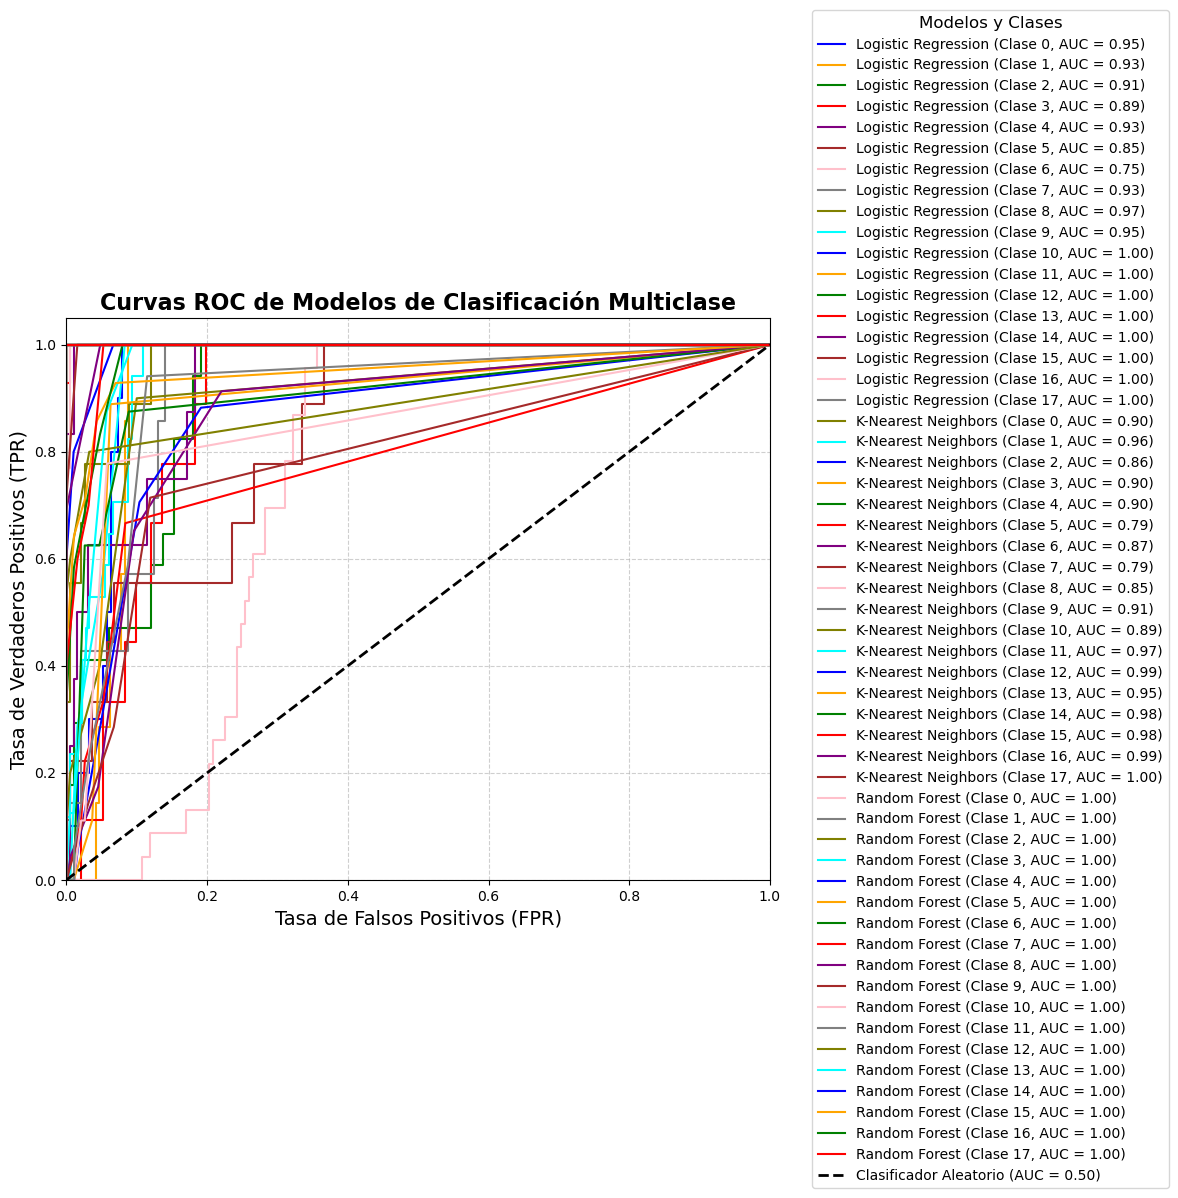

In [ ]:
# Crear un gráfico para visualizar las curvas ROC
plt.figure(figsize=(12, 10))

# Colores para las curvas
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
color_idx = 0

for model_name, model in models.items():
    # One-vs-Rest para manejar la clasificación multiclase
    classifier = OneVsRestClassifier(model)
    classifier.fit(X_train, y_train)
    
    # Obtener las probabilidades de predicción
    y_prob = classifier.predict_proba(X_test)
    
    # Calcular la curva ROC y AUC para cada clase
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=1.5, color=colors[color_idx % len(colors)],
                 label=f'{model_name} (Clase {i}, AUC = {roc_auc:.2f})')
        color_idx += 1

# Graficar la línea diagonal de no discriminación (AUC = 0.5)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', lw=2, label='Clasificador Aleatorio (AUC = 0.50)')

# Etiquetas y título
plt.title('Curvas ROC de Modelos de Clasificación Multiclase', fontsize=16, fontweight='bold')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=10, title="Modelos y Clases", title_fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar el diseño para evitar que el texto se solape
plt.tight_layout()

# Mostrar el gráfico
plt.show()


## Resultados del AUC

### Random Forest
- **Desempeño**:
  - El modelo Random Forest muestra el mejor desempeño, con un AUC de 1.00 en todas las clases evaluadas.

### Logistic Regression
- **Desempeño**:
  - Logistic Regression tiene un desempeño competitivo, con AUC altos, aunque ligeramente menores que Random Forest en algunas clases.

### K-Nearest Neighbors (KNN)
- **Desempeño**:
  - K-Nearest Neighbors tiene un desempeño más variable, con algunas clases por debajo de AUC = 0.9, lo que podría indicar una menor capacidad de discriminación en comparación con los otros modelos.